## Tarea 1 - Análisis de Texto  
### Jessica Lizeth Hernández Bracho 1842553



### Guiones de los episodios piloto ($1 \times 01$) de Malcolm in the Middle vs. Modern Family.

*Objetivo: Analizar y comparar la estructura lingüística y los rasgos estilísticos de dos producciones televisivas icónicas: **Malcolm in the Middle** y **Modern Family**.*

### 1. Carga de archivos

In [ ]:
# Carga de texto del episodio uno de cada serie
with open("mitm_s1e1.txt", "r", encoding="utf-8") as f:
    texto_malcolm = f.read()

with open("mf_s1e1.txt", "r", encoding="utf-8") as f:
    texto_modern = f.read()

# Primeros caracteres
print("Malcolm:", texto_malcolm[:300])
print("Modern Family:", texto_modern[:300])

Malcolm: This is the world--

196 million square miles.

If I covered 100 square miles
an hour

every hour
for the rest of my life

I'd still only see half of it.

This is the left nostril
of my brother Reese.

It squeaks all night long.

These are
the freezing cold feet

of my little brother... Dewey.

This
Modern Family: [Claire]
Kids, breakfast!

Kids? [Sighs]
Phil, would you get them?
[Video Game Sounds]

Yeah. Just a sec.

Kids!

That is-
Okay.

Kids? Get down here!

Why are you guys yelling at us
when we're way upstairs?

Just text me.
All right.
That's not gonna happen.

And, wow! You're not
wearing that outfit


### 2. Limpieza y Tokenizacion

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
ps = PorterStemmer()

In [ ]:
def tokens_clase(txt, idioma = 'english'):
    # 1. Quitar signos y pasar a minúsculas
    texto_limpio = re.sub(r'[^ɵ\w\s]', '', txt.lower())

    # 2. Cargar stopwords
    stop_words = set(stopwords.words(idioma))
    ruido_guiones = ['dont', 'im', 'youre', 'cant', 'ive', 'oh', 'hey', 'yeah', 'gonna', 'wanna', 'gotta', 'gon', 'wan', 'na', 'ta']
    for word in ruido_guiones:
        stop_words.add(word)

    # 3. Tokenizar y filtrar
    tokens_totales = word_tokenize(texto_limpio)
    texto_filtrado = [word for word in tokens_totales if word not in stop_words]

    tokens_stemmed = [ps.stem(palabra) for palabra in texto_filtrado]

    return tokens_stemmed

# Aplicamos la función a cada texto
tokens_malcolm = tokens_clase(texto_malcolm)
tokens_modern = tokens_clase(texto_modern)

# Resultado
print("Tokens Malcolm:", tokens_malcolm[:15])
print("Tokens Modern Family:", tokens_modern[:15])

Tokens Malcolm: ['world', '196', 'million', 'squar', 'mile', 'cover', '100', 'squar', 'mile', 'hour', 'everi', 'hour', 'rest', 'life', 'id']
Tokens Modern Family: ['clair', 'kid', 'breakfast', 'kid', 'sigh', 'phil', 'would', 'get', 'video', 'game', 'sound', 'sec', 'kid', 'okay', 'kid']


Se utilizó la librería `NLTK` para:

1. **Lectura de Archivos:** Carga de los guiones en texto plano (`.txt`), asegurando textos limpios.
2. **Normalización:** Conversión total de strings a minúsculas y remoción de caracteres especiales y signos de puntuación mediante expresiones regulares (`re.sub`).
3. **Tokenización:** Segmentación del texto corrido en unidades discretas de palabras (tokens) a través de `word_tokenize`.
4. **Filtrado de Palabras Vacías (*Stop Words*):** Remoción de conectores y artículos de alta frecuencia pero nulo valor semántico empleando el diccionario nativo en inglés de NLTK.
    * *Nota:* Se expandió la lista de stop words para mitigar el ruido sintáctico generado por el tokenizador al fragmentar contracciones informales propias de los guiones (ej. *gonna* a `gon` y `na`).
5. **Reducción de Desinencias (*Stemming*):** Aplicación del algoritmo `PorterStemmer` para reducir las flexiones de las palabras a sus raíces básicas y unificar el conteo de frecuencias.

### 3. Conteo de Frecuencias

In [ ]:
import pandas as pd

In [ ]:
# ANÁLISIS DE MALCOLM
df_malcolm = pd.DataFrame(tokens_malcolm, columns=['token'])
frec_malcolm = df_malcolm.value_counts().to_frame().reset_index()
frec_malcolm.columns = ['token', 'conteo']

print("TOP 10 PALABRAS MALCOLM")
print(frec_malcolm.head(10))

TOP 10 PALABRAS MALCOLM
     token  conteo
0  malcolm      33
1     okay      25
2     know      24
3       go      23
4     want      20
5     like      20
6      get      19
7     make      16
8      mom      15
9    right      14


In [ ]:
# ANÁLISIS DE MODERN FAMILY
df_modern = pd.DataFrame(tokens_modern, columns=['token'])
frec_modern = df_modern.value_counts().to_frame().reset_index()
frec_modern.columns = ['token', 'conteo']

print("TOP 10 PALABRAS MODERN FAMILY")
print(frec_modern.head(10))

TOP 10 PALABRAS MODERN FAMILY
   token  conteo
0   know      33
1   okay      30
2   that      24
3   like      21
4    dad      21
5  right      19
6    say      18
7    get      18
8     uh      18
9   come      17


### 4. Métricas

- Conteo de Signos de Puntuación

In [ ]:
# Contar exclamaciones e interrogaciones directamente en el texto original
print("ANÁLISIS DE SIGNOS DE PUNTUACIÓN")
print(f"Malcolm - Signos de Exclamación (!): {texto_malcolm.count('!')}")
print(f"Malcolm - Signos de Interrogación (?): {texto_malcolm.count('?')}")

print(f"\nModern Family - Signos de Exclamación (!): {texto_modern.count('!')}")
print(f"Modern Family - Signos de Interrogación (?): {texto_modern.count('?')}")

ANÁLISIS DE SIGNOS DE PUNTUACIÓN
Malcolm - Signos de Exclamación (!): 55
Malcolm - Signos de Interrogación (?): 89

Modern Family - Signos de Exclamación (!): 62
Modern Family - Signos de Interrogación (?): 104


Interpretación: Los datos demuestran un volumen superior tanto de signos de exclamación como de interrogación en el episodio piloto de **Modern Family**. Desde una perspectiva analítica, esto refleja el estilo de ritmo rápido y la estructura de enredos simultáneos del show. El piloto de *Modern Family* se caracteriza por la alta tensión cómica debido a malentendidos, preguntas constantes entre los protagonistas, y situaciones caóticas, lo que satura el guion de marcas expresivas y cuestionamientos interactivos.

- Mejor vocabulario de cada serie

In [ ]:
# Fórmula: Palabras únicas / Palabras totales
voc_malcolm = len(set(tokens_malcolm)) / len(tokens_malcolm)
voc_modern = len(set(tokens_modern)) / len(tokens_modern)

print(f"Vocabulario de Malcolm: {voc_malcolm:.3f}")
print(f"Vocabulario de Modern Family: {voc_modern:.3f}")

Vocabulario de Malcolm: 0.423
Vocabulario de Modern Family: 0.400


Interpretación: El análisis estadístico reveló que **Malcolm in the Middle** exhibe una riqueza léxica superior (42.3% de palabras únicas) en comparación con *Modern Family* (40.0%). A pesar de que *Modern Family* cuenta con un elenco más amplio, el guion de *Malcolm* se apoya de forma masiva en el monólogo interno y la narración en primera persona del protagonista hacia la cámara.

### 6. n-Gramas (Bigramas) y Grafos de Palabras

In [ ]:
from nltk import ngrams
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

In [ ]:
# BIGRAMAS EN MALCOLM
# Generamos los bigramas a partir de la lista de tokens limpios
bigr_malcolm = list(ngrams(tokens_malcolm, 2))
# Contamos cuáles son los más comunes
topbigr_malcolm = Counter(bigr_malcolm).most_common(5)

print("TOP 5 BIGRAMAS MALCOLM")
for grama, conteo in topbigr_malcolm:
    print(f"{grama}: {conteo} veces")

TOP 5 BIGRAMAS MALCOLM
('wait', 'wait'): 5 veces
('hold', 'hand'): 4 veces
('spath', 'spath'): 3 veces
('go', 'special'): 3 veces
('special', 'class'): 3 veces


In [ ]:
# BIGRAMAS EN MODERN FAMILY
bigr_modern = list(ngrams(tokens_modern, 2))
topbigr_modern = Counter(bigr_modern).most_common(5)

print("TOP 5 BIGRAMAS MODERN FAMILY")
for grama, conteo in topbigr_modern:
    print(f"{grama}: {conteo} veces")

TOP 5 BIGRAMAS MODERN FAMILY
('hi', 'hi'): 4 veces
('thank', 'thank'): 4 veces
('let', 'see'): 4 veces
('dad', 'dad'): 3 veces
('first', 'time'): 3 veces


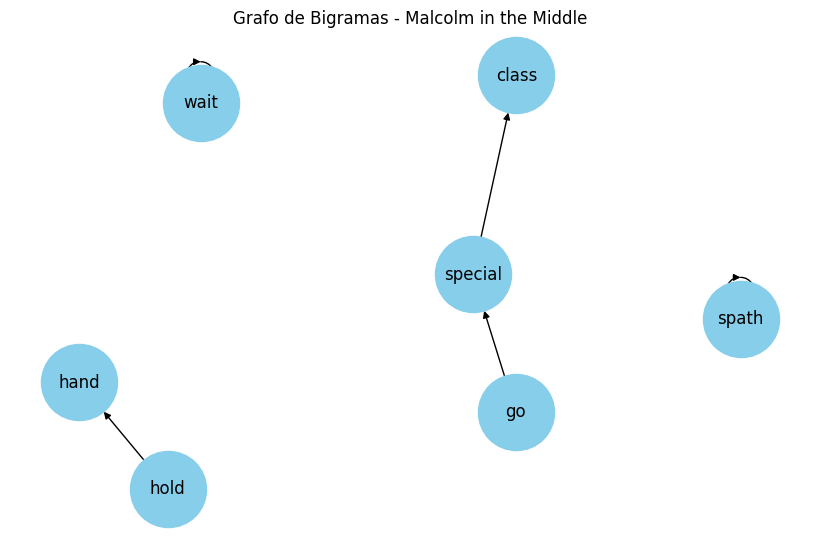

In [ ]:
# Bigramas de Malcolm
G = nx.DiGraph()

# Agregamos los 5 bigramas más comunes al grafo
for grama, conteo in topbigr_malcolm:
    G.add_edge(grama[0], grama[1])

plt.figure(figsize=(8, 5))

pos = nx.spring_layout(G, k=0.8)
nx.draw(G, pos, with_labels=True, node_size=3000, font_size=12, node_color="skyblue")
plt.title("Grafo de Bigramas - Malcolm in the Middle")
plt.show()

En el grafo de *Malcolm*, la conexión cerrada y adyacente entre los nodos `special` y `class` representa un hallazgo crítico de la minería de texto. El algoritmo fue capaz de extraer de forma totalmente automatizada el núcleo argumental de la primera temporada.  
En *Malcolm*, la presencia del bucle en el token `wait` (*"wait, wait!"*) refleja urgencia y conflicto verbal.

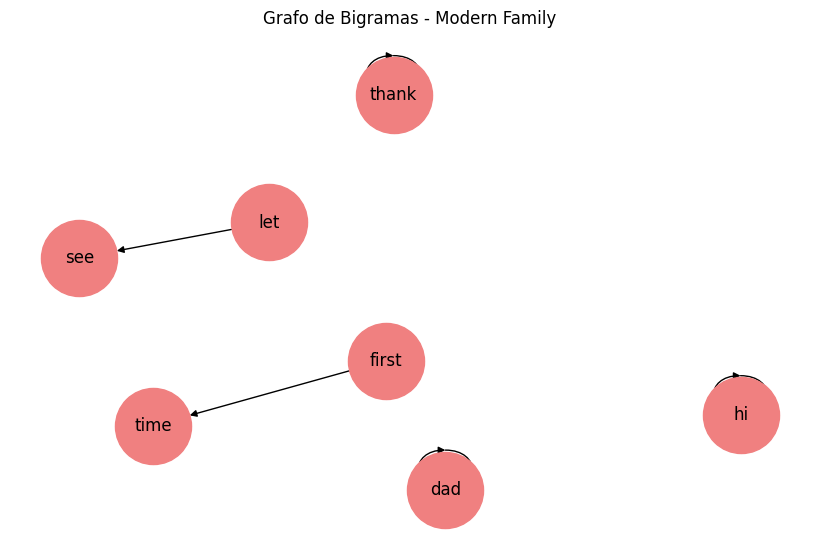

In [ ]:
# Bigramas para Modern Family
G_modern = nx.DiGraph()

# Agregamos los 5 bigramas más comunes de Modern Family al grafo
for grama, conteo in topbigr_modern:
    G_modern.add_edge(grama[0], grama[1])

plt.figure(figsize=(8, 5))

pos = nx.spring_layout(G_modern, k=0.8)
nx.draw(G_modern, pos, with_labels=True, node_size=3000, font_size=12, node_color="lightcoral")
plt.title("Grafo de Bigramas - Modern Family")
plt.show()

### 8. Gráficas de Barras Comparativas

/tmp/ipykernel_1419/2275629305.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(frec_malcolm.iloc[:10].token, rotation=45)
/tmp/ipykernel_1419/2275629305.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(frec_modern.iloc[:10].token, rotation=45)


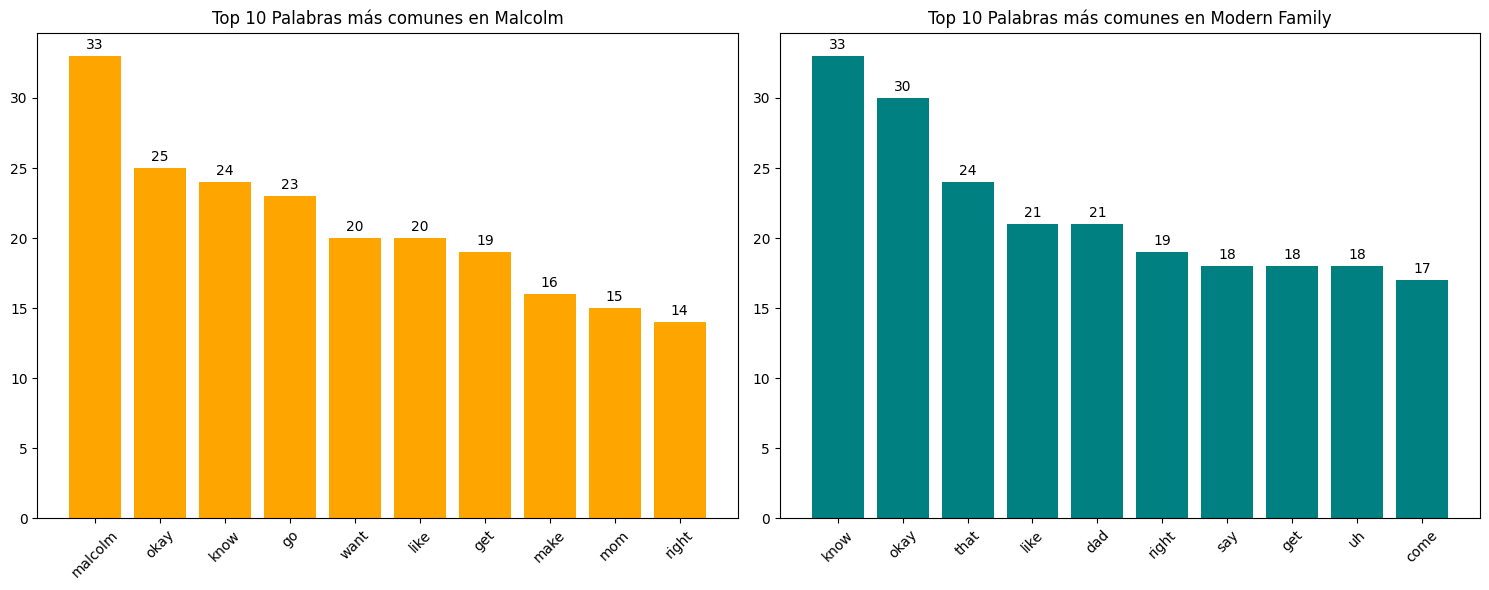

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Malcolm
barras1 = ax[0].bar(frec_malcolm.iloc[:10].token, frec_malcolm.iloc[:10].conteo, color='orange')
ax[0].set_title("Top 10 Palabras más comunes en Malcolm")
ax[0].set_xticklabels(frec_malcolm.iloc[:10].token, rotation=45)

ax[0].bar_label(barras1, padding=3)

# Gráfica 2: Modern Family
barras2 = ax[1].bar(frec_modern.iloc[:10].token, frec_modern.iloc[:10].conteo, color='teal')
ax[1].set_title("Top 10 Palabras más comunes en Modern Family")
ax[1].set_xticklabels(frec_modern.iloc[:10].token, rotation=45)

ax[1].bar_label(barras2, padding=3)

plt.tight_layout()
plt.show()